In [22]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
path = str(Path.cwd())
print(path)
sys.path.insert(1, path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/joaquin/Documents/GitHub/skforecast/dev/arima


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from arima import ARIMA as ARIMACUSTOM
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from aeon.datasets import load_airline
from statsforecast.models import ARIMA
from skforecast.datasets import fetch_dataset
import warnings
import time

In [45]:
# Data set 1: Fuel Consumption
data = fetch_dataset(name='fuel_consumption', raw=True, verbose=False)
# data = data[['Fecha', 'Gasolinas']]
# data = data.rename(columns={'Fecha':'date', 'Gasolinas':'litters'})
# data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
# data = data.set_index('date')
# data = data.loc[:'1990-01-01 00:00:00']
# data = data.asfreq('MS')
# data = data[['litters']]
# data = data.rename(columns={'litters': 'y'})
# data['month'] = data.index.month.astype('float')
# end_train = '1980-01-01 23:59:59'
# data_train = data.loc[:end_train]
# data_test  = data.loc[end_train:]
# print(f"Train samples: {len(data_train)}")
# print(f"Test samples:  {len(data_test)}")

# Data set 2: Airline Passengers
# data = load_airline(return_array=False).to_frame(name='y')
# data = data.asfreq('M')
# data['month'] = data.index.month.astype('float')
# end_train = '1957-12-01 23:59:59'
# data_train = data.loc[:end_train]
# data_test  = data.loc[end_train:]
# print(f"Train samples: {len(data_train)}")
# print(f"Test samples:  {len(data_test)}")

# Data set 3: Website Visits
data = fetch_dataset(name="website_visits", raw=True, verbose=False)
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%y')
data = data.set_index('date')
data = data.asfreq('1D')
data = data.sort_index()
data = data.rename(columns={'users': 'y'})
data['month'] = data.index.month.astype('float')
end_train = '2021-06-30 23:59:00'
data_train = data.loc[: end_train, :]
data_test  = data.loc[end_train:, :]

data

,y,month
date,,
2020-07-01,2324,7.0
2020-07-02,2201,7.0
2020-07-03,2146,7.0
2020-07-04,1666,7.0
2020-07-05,1433,7.0
...,...,...
2021-08-21,1546,8.0
2021-08-22,1393,8.0
2021-08-23,2371,8.0


In [42]:
# data = sm.datasets.get_rdataset("AirPassengers").data
# data = data[['value']]
# data = data.rename(columns={'value': 'y'})
# data_train = data.iloc[:120]
# data_test = data.iloc[120:]


# data = sm.datasets.sunspots.load_pandas().data
# data = data.rename(columns={'SUNACTIVITY': 'y'})
# data_train = data.iloc[:250]
# data_test = data.iloc[250:]

In [48]:
order = (12, 1, 1)
trend = None  # 'n', 'c', 't', 'ct'
exog = None # data_train[['month']]
exog_test = None # data_test[['month']]


print("Fitting Statsmodels SARIMAX...")
warnings.filterwarnings("ignore") # Suppress convergence warnings for cleaner output
start_time = time.time()
sm_model = SARIMAX(endog=data_train['y'],
                   exog=exog,
                   order=order, 
                   trend=trend
                ) 
sm_res = sm_model.fit(disp=0)
sm_pred = sm_res.get_forecast(steps=len(data_test), exog=exog_test).predicted_mean
print(f"Statsmodels fitting time: {time.time() - start_time:.2f} seconds\n")
print(f"Model parameters:\n{sm_res.params}\n")

print("Fitting Custom arima...")
start_time = time.time()
arimax_model = ARIMACUSTOM(order=order)
arimax_model.fit(y=data_train['y'])
arimax_pred_values = arimax_model.predict(steps=len(data_test))
arimax_pred = pd.Series(arimax_pred_values, index=data_test.index)
print(f"Custom arima fitting time: {time.time() - start_time:.2f} seconds\n")
print(f"Model parameters:\n{arimax_model.ar_coef_} {arimax_model.ma_coef_} {arimax_model.intercept_}\n")

print("Fitting StatsForecast ARIMA...")
start_time = time.time()
sf_model = ARIMA(order=order)
sf_model.fit(y=data_train['y'], X=exog.to_numpy() if exog is not None else None)
sf_pred_values = sf_model.predict(h=len(data_test), X=exog_test.to_numpy() if exog_test is not None else None)
sf_pred = pd.Series(sf_pred_values['mean'], index=data_test.index)
print(f"StatsForecast ARIMA fitting time: {time.time() - start_time:.2f} seconds\n")
print(f"Model parameters:\n{sf_model.model_['coef']}\n")

Fitting Statsmodels SARIMAX...
Statsmodels fitting time: 8.44 seconds

Model parameters:
ar.L1         0.181523
ar.L2        -0.256701
ar.L3         0.065591
ar.L4        -0.098032
ar.L5        -0.069582
ar.L6        -0.024947
ar.L7         0.673747
ar.L8        -0.187637
ar.L9         0.055305
ar.L10       -0.159245
ar.L11       -0.041111
ar.L12       -0.087890
ma.L1        -0.230974
sigma2    72307.263282
dtype: float64

Fitting Custom arima...
Custom arima fitting time: 0.01 seconds

Model parameters:
[ 0.16869636 -0.26045582  0.06326357 -0.09686085 -0.07528137 -0.02209835
  0.67720649 -0.17890626  0.05646197 -0.16358624 -0.04287261 -0.09249309] [-0.21311045] 0.0

Fitting StatsForecast ARIMA...
StatsForecast ARIMA fitting time: 0.21 seconds

Model parameters:
{'ar1': np.float64(0.16834627966525884), 'ar2': np.float64(-0.2603611818966061), 'ar3': np.float64(0.06324647686787141), 'ar4': np.float64(-0.09676361059621706), 'ar5': np.float64(-0.07522826625220194), 'ar6': np.float64(-0.021

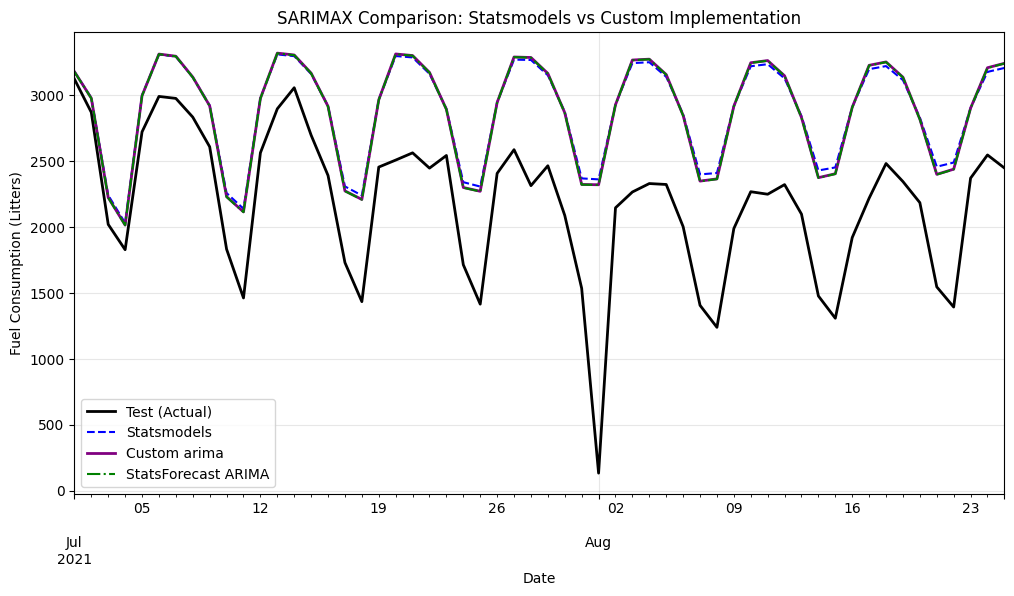

,MAE
Model,
StatsForecast ARIMA,691.475371
Custom arima,692.903242
Statsmodels SARIMAX,697.796419


In [50]:
# Visualization & Comparison
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
# data_train.loc[:end_train, 'y'].plot(label='Train (Last 5 Years)', color='gray', alpha=0.5, ax=ax)
data_test['y'].plot(label='Test (Actual)', color='black', linewidth=2, ax=ax)
sm_pred.plot(label='Statsmodels', linestyle='--', color='blue', ax=ax)
arimax_pred.plot(label='Custom arima', linestyle='-', color='purple', linewidth=2, ax=ax)
sf_pred.plot(label='StatsForecast ARIMA', linestyle='-.', color='green', ax=ax)
plt.title('SARIMAX Comparison: Statsmodels vs Custom Implementation')
plt.xlabel('Date')
plt.ylabel('Fuel Consumption (Litters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Numerical Error Comparison
# -----------------------------------------------------------------------------
mae_sm = (data_test['y'] - sm_pred).abs().mean()
mae_sf = (data_test['y'] - sf_pred).abs().mean()
mae_arimax = (data_test['y'] - arimax_pred).abs().mean()

pd.DataFrame({
    'Model': ['Statsmodels SARIMAX', 'StatsForecast ARIMA', 'Custom arima'],
    'MAE': [mae_sm, mae_sf, mae_arimax]
}).set_index('Model').sort_values(by='MAE')

In [29]:
pd.DataFrame({
    'Statsmodels': sm_pred,
    'Custom arima': arimax_pred,
    'StatsForecast ARIMA': sf_pred
})

,Statsmodels,Custom arima,StatsForecast ARIMA
1980-02-01,422456.679181,425600.219905,422753.364615
1980-03-01,425479.462918,432475.894731,427188.580187
1980-04-01,435176.874517,445879.096278,438491.496764
1980-05-01,429915.851672,441013.794198,432203.247863
1980-06-01,429919.524778,442149.412112,431520.454766
...,...,...,...
1989-09-01,429912.659177,650280.401944,431837.489972
1989-10-01,429912.659177,652151.697768,431837.489972
1989-11-01,429912.659177,654022.993593,431837.489972
1989-12-01,429912.659177,655894.289417,431837.489972


# Comprehensive Parameter Testing

Let's test various ARIMA configurations to validate the implementation across different model complexities.

In [33]:
# Test different ARIMA configurations
import numpy as np

test_orders = [
    (1, 0, 0),   # Simple AR(1) - no differencing
    (0, 0, 1),   # Simple MA(1) - no differencing
    (1, 0, 1),   # ARMA(1,1) - no differencing
    (2, 1, 0),   # AR(2) with differencing
    (0, 1, 2),   # MA(2) with differencing
    (1, 1, 1),   # ARMA(1,1) with differencing
    (2, 1, 1),   # ARMA(2,1) with differencing
    (3, 1, 1),   # Current best (ARMA(3,1) with differencing)
    (2, 1, 2),   # ARMA(2,2) with differencing
    (1, 2, 1),   # ARMA(1,1) with second-order differencing
]

results = []

for order in test_orders:
    print(f"\nTesting ARIMA{order}...")
    
    try:
        # Custom ARIMA
        start_time = time.time()
        custom_model = ARIMACUSTOM(order=order)
        custom_model.fit(y=data_train['y'])
        custom_pred = custom_model.predict(steps=len(data_test))
        custom_time = time.time() - start_time
        custom_mae = np.abs(data_test['y'].values - custom_pred).mean()
        
        # Statsmodels SARIMAX
        start_time = time.time()
        sm_model = SARIMAX(endog=data_train['y'], order=order, trend=None)
        sm_res = sm_model.fit(disp=0)
        sm_pred = sm_res.get_forecast(steps=len(data_test)).predicted_mean
        sm_time = time.time() - start_time
        sm_mae = np.abs(data_test['y'].values - sm_pred.values).mean()
        
        # StatsForecast ARIMA
        start_time = time.time()
        sf_model = ARIMA(order=order)
        sf_model.fit(y=data_train['y'])
        sf_pred_values = sf_model.predict(h=len(data_test))
        sf_time = time.time() - start_time
        sf_mae = np.abs(data_test['y'].values - sf_pred_values['mean']).mean()
        
        # Calculate differences
        diff_sm = np.abs(custom_pred - sm_pred.values).mean()
        diff_sf = np.abs(custom_pred - sf_pred_values['mean']).mean()
        
        results.append({
            'Order': f"ARIMA{order}",
            'Custom MAE': f"{custom_mae:.0f}",
            'SM MAE': f"{sm_mae:.0f}",
            'SF MAE': f"{sf_mae:.0f}",
            'Diff vs SM': f"{diff_sm:.0f}",
            'Diff vs SF': f"{diff_sf:.0f}",
            'Custom Time': f"{custom_time:.3f}s",
            'SM Time': f"{sm_time:.3f}s",
            'SF Time': f"{sf_time:.3f}s",
        })
        
        print(f"  ✓ Custom MAE: {custom_mae:.0f} | SM MAE: {sm_mae:.0f} | SF MAE: {sf_mae:.0f}")
        print(f"    Pred diff vs SM: {diff_sm:.0f} | vs SF: {diff_sf:.0f}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:100]}")
        results.append({
            'Order': f"ARIMA{order}",
            'Custom MAE': 'ERROR',
            'SM MAE': '-',
            'SF MAE': '-',
            'Diff vs SM': '-',
            'Diff vs SF': '-',
            'Custom Time': '-',
            'SM Time': '-',
            'SF Time': '-',
        })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("COMPREHENSIVE COMPARISON RESULTS")
print("="*100)
results_df


Testing ARIMA(1, 0, 0)...
  ✓ Custom MAE: 176572 | SM MAE: 277700 | SF MAE: 175776
    Pred diff vs SM: 102331 | vs SF: 796

Testing ARIMA(0, 0, 1)...
  ✓ Custom MAE: 180667 | SM MAE: 536617 | SF MAE: 182646
    Pred diff vs SM: 355950 | vs SF: 1978

Testing ARIMA(1, 0, 1)...
  ✓ Custom MAE: 176304 | SM MAE: 256537 | SF MAE: 167610
    Pred diff vs SM: 83647 | vs SF: 8694

Testing ARIMA(2, 1, 0)...
  ✓ Custom MAE: 115481 | SM MAE: 116549 | SF MAE: 115696
    Pred diff vs SM: 1220 | vs SF: 243

Testing ARIMA(0, 1, 2)...
  ✓ Custom MAE: 71881 | SM MAE: 111506 | SF MAE: 100298
    Pred diff vs SM: 65854 | vs SF: 51851

Testing ARIMA(1, 1, 1)...
  ✓ Custom MAE: 72232 | SM MAE: 85894 | SF MAE: 84595
    Pred diff vs SM: 28039 | vs SF: 25913

Testing ARIMA(2, 1, 1)...
  ✓ Custom MAE: 72570 | SM MAE: 84139 | SF MAE: 82104
    Pred diff vs SM: 23755 | vs SF: 20329

Testing ARIMA(3, 1, 1)...
  ✓ Custom MAE: 108745 | SM MAE: 110318 | SF MAE: 108719
    Pred diff vs SM: 1882 | vs SF: 41

Testing

,Order,Custom MAE,SM MAE,SF MAE,Diff vs SM,Diff vs SF,Custom Time,SM Time,SF Time
0,"ARIMA(1, 0, 0)",176572,277700,175776,102331,796,0.001s,0.027s,0.020s
1,"ARIMA(0, 0, 1)",180667,536617,182646,355950,1978,0.002s,0.039s,0.182s
2,"ARIMA(1, 0, 1)",176304,256537,167610,83647,8694,0.001s,0.064s,0.250s
3,"ARIMA(2, 1, 0)",115481,116549,115696,1220,243,0.001s,0.034s,0.018s
4,"ARIMA(0, 1, 2)",71881,111506,100298,65854,51851,0.001s,0.033s,0.020s
5,"ARIMA(1, 1, 1)",72232,85894,84595,28039,25913,0.002s,0.086s,0.035s
6,"ARIMA(2, 1, 1)",72570,84139,82104,23755,20329,0.003s,0.085s,0.043s
7,"ARIMA(3, 1, 1)",108745,110318,108719,1882,41,0.003s,0.116s,0.038s
8,"ARIMA(2, 1, 2)",110903,78203,74410,45503,58274,0.006s,0.304s,0.063s
9,"ARIMA(1, 2, 1)",805016,72196,183423,844499,621630,0.002s,0.083s,0.028s


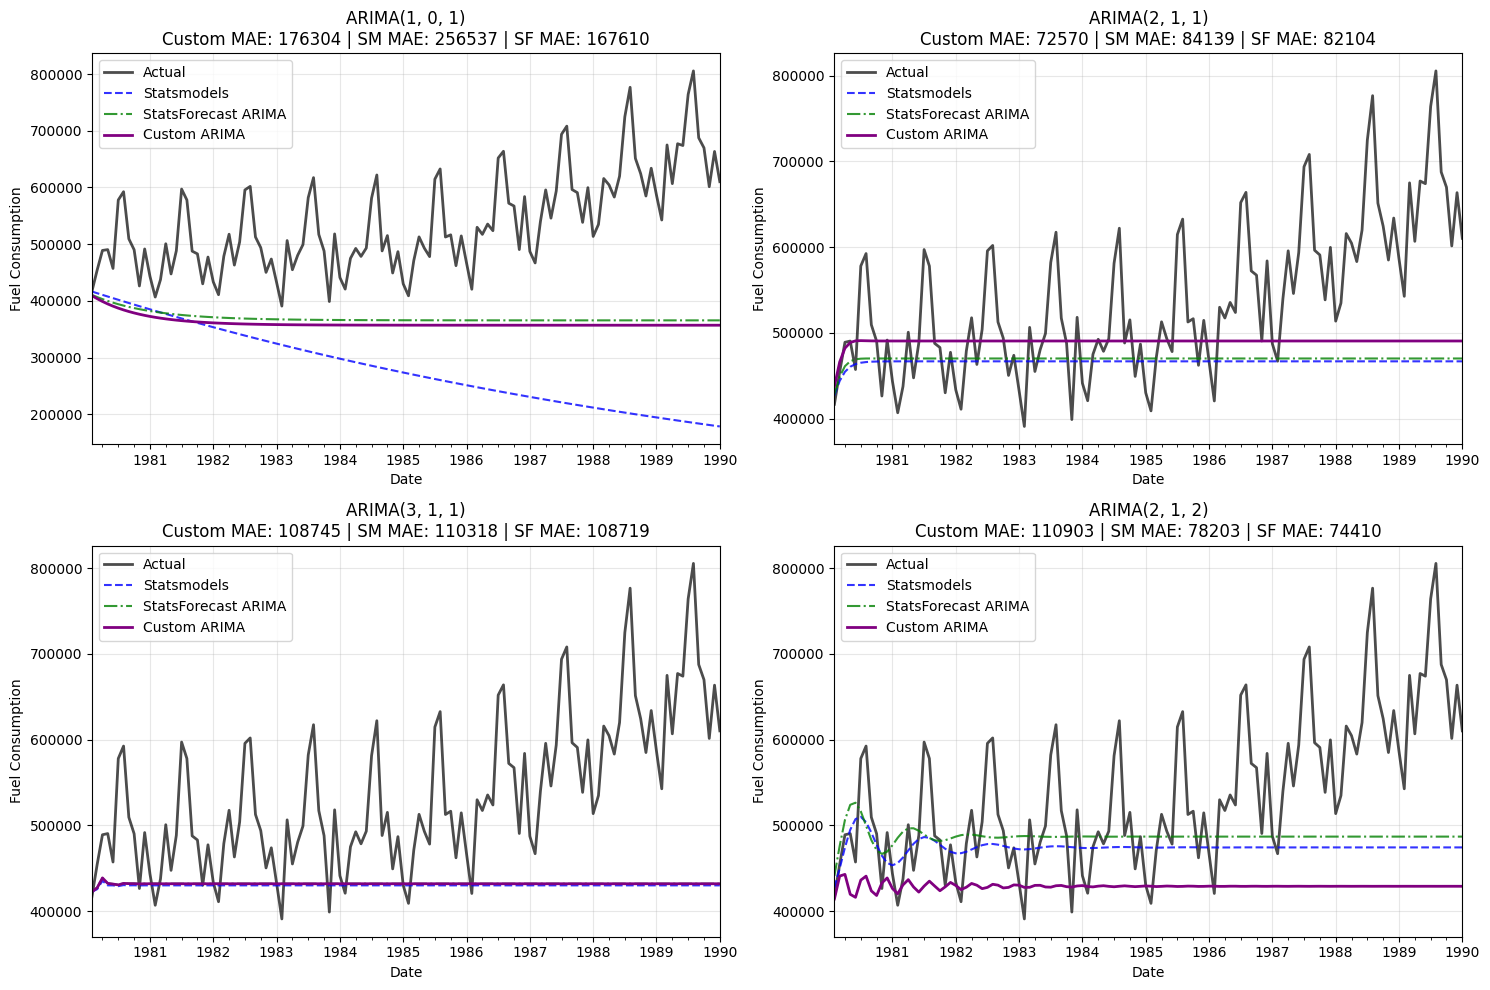

In [39]:
# Visualize best performing models
best_models = [
    (1, 0, 1),   # ARMA(1,1) - no differencing
    (2, 1, 1),   # ARMA(2,1) with differencing  
    (3, 1, 1),   # ARMA(3,1) with differencing
    (2, 1, 2),   # ARMA(2,2) with differencing
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, order in enumerate(best_models):
    ax = axes[idx]
    
    # Fit models
    custom_model = ARIMACUSTOM(order=order)
    custom_model.fit(y=data_train['y'])
    custom_pred = custom_model.predict(steps=len(data_test))
    
    sm_model = SARIMAX(endog=data_train['y'], order=order, trend=None)
    sm_res = sm_model.fit(disp=0)
    sm_pred = sm_res.get_forecast(steps=len(data_test)).predicted_mean

    sf_model = ARIMA(order=order)
    sf_model.fit(y=data_train['y'])
    sf_pred_values = sf_model.predict(h=len(data_test))
    sf_pred = pd.Series(sf_pred_values['mean'], index=data_test.index)
    
    # Plot
    data_test['y'].plot(label='Actual', color='black', linewidth=2, ax=ax, alpha=0.7)
    sm_pred.plot(label='Statsmodels', linestyle='--', color='blue', ax=ax, alpha=0.8)
    sf_pred.plot(label='StatsForecast ARIMA', linestyle='-.', color='green', ax=ax, alpha=0.8)
    pd.Series(custom_pred, index=data_test.index).plot(
        label='Custom ARIMA', linestyle='-', color='purple', linewidth=2, ax=ax
    )
    
    # Calculate errors
    custom_mae = np.abs(data_test['y'].values - custom_pred).mean()
    sm_mae = np.abs(data_test['y'].values - sm_pred.values).mean()
    sf_mae = np.abs(data_test['y'].values - sf_pred.values).mean()
    
    ax.set_title(f'ARIMA{order}\nCustom MAE: {custom_mae:.0f} | SM MAE: {sm_mae:.0f} | SF MAE: {sf_mae:.0f}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Fuel Consumption')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()